In [1]:
%pip install -q requests ipywidgets networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.5 MB/s eta 0:00:00


In [42]:

REPO_URL = "https://github.com/psf/requests"   # any public GitHub repo URL
PROVIDER = "groq"

API_KEY = None

MODEL_OVERRIDE = None
SKIP_AI_SUMMARY = True    # True = for structural analysis, without API key, if false need API key


In [43]:
import ast
import getpass
import json
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path



In [44]:
import requests
from IPython.display import display, Markdown, HTML, FileLink

IGNORE_DIRS = {
    ".git", "node_modules", "__pycache__", "venv", ".venv", "env",
    "dist", "build", ".next", ".idea", ".vscode", ".mypy_cache",
    ".pytest_cache", "coverage", ".tox", "target", "vendor", ".turbo",
}

CODE_EXTENSIONS = {
    # Python
    ".py": "python",

    # JavaScript
    ".js": "javascript",
    ".jsx": "javascript",
    ".mjs": "javascript",
    ".cjs": "javascript",

    # TypeScript
    ".ts": "typescript",
    ".tsx": "typescript",

    # Web
    ".html": "html",
    ".htm": "html",
    ".xhtml": "html",

    ".css": "css",
    ".scss": "scss",
    ".sass": "sass",
    ".less": "less",

    # Templates
    ".vue": "vue",
    ".svelte": "svelte",
    ".astro": "astro",

    # Data / Config
    ".json": "json",
    ".json5": "json",
    ".yaml": "yaml",
    ".yml": "yaml",
    ".toml": "toml",
    ".xml": "xml",

    # Markdown
    ".md": "markdown",
    ".mdx": "mdx",

    # Shell
    ".sh": "bash",
    ".bash": "bash",
    ".zsh": "zsh",
    ".ps1": "powershell",
    ".bat": "batch",
    ".cmd": "batch",

    # Languages
    ".java": "java",
    ".go": "go",
    ".rb": "ruby",
    ".rs": "rust",
    ".php": "php",
    ".c": "c",
    ".h": "c",
    ".cpp": "cpp",
    ".cc": "cpp",
    ".cxx": "cpp",
    ".hpp": "cpp",
    ".hh": "cpp",
    ".cs": "csharp",
    ".kt": "kotlin",
    ".swift": "swift",
    ".scala": "scala",
    ".r": "r",
    ".sql": "sql",
    ".lua": "lua",
    ".dart": "dart",
    ".ex": "elixir",
    ".exs": "elixir",
    ".erl": "erlang",
    ".fs": "fsharp",
    ".jl": "julia",
    ".pl": "perl",
    ".m": "objective-c",
    ".mm": "objective-c++",

    # Docker / Infrastructure
    ".dockerfile": "dockerfile",
    ".tf": "terraform",
    ".tfvars": "terraform",

    # Notebooks
    ".ipynb": "jupyter",
}



In [45]:
MAX_FILE_BYTES = 2_000_000   # no more than this
MAX_FILES = 2000

LANG_COLORS = {
    "python": "#5eead4", "javascript": "#f5d423", "typescript": "#5b9cf5",
    "java": "#e88b4b", "go": "#4bd0e8", "ruby": "#e8556e", "rust": "#e8813f",
    "php": "#9a7de8", "c": "#8ba3b5", "cpp": "#8ba3b5", "csharp": "#a15be8",
    "kotlin": "#c98be8", "swift": "#e8724b", "unknown": "#9aa5ad",
}

print("Constants loaded.")


Constants loaded.


In [46]:
# --- Cloning & file discovery -------------------------------------------

def clone_repo(repo_url: str, dest_dir: str) -> str:
    """Shallow-clone a GitHub repo (or any git URL) into dest_dir."""
    cmd = ["git", "clone", "--depth", "1", repo_url, dest_dir]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or "git clone failed")
    return dest_dir


def iter_source_files(root: str):
    count = 0
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if d not in IGNORE_DIRS and not d.startswith(".git")]
        for fname in filenames:
            ext = Path(fname).suffix
            if ext not in CODE_EXTENSIONS:
                continue
            full = Path(dirpath) / fname
            try:
                if full.stat().st_size > MAX_FILE_BYTES:
                    continue
            except OSError:
                continue
            count += 1
            if count > MAX_FILES:
                return
            yield full


def read_text(path: Path) -> str:
    try:
        return path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return ""


print("Cloning & discovery functions loaded.")


Cloning & discovery functions loaded.


In [47]:
# --- Python parsing -----------

def parse_python(path: Path, root: Path) -> dict:
    src = read_text(path)
    rel = path.relative_to(root).as_posix()
    data = {
        "path": rel, "language": "python", "imports": [], "classes": [], "functions": [],
        "is_entry_point": False, "entry_point_reasons": [],
        "loc": (src.count("\n") + 1) if src else 0,
    }
    try:
        tree = ast.parse(src, filename=rel)
    except SyntaxError:
        data["parse_error"] = True
        return data

    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            for alias in node.names:
                data["imports"].append({"module": alias.name, "type": "import"})
        elif isinstance(node, ast.ImportFrom):
            prefix = "." * (node.level or 0)
            data["imports"].append({"module": f"{prefix}{node.module or ''}", "type": "from"})
        elif isinstance(node, ast.ClassDef):
            bases = []
            for b in node.bases:
                try:
                    bases.append(ast.unparse(b))
                except Exception:
                    bases.append("base")
            data["classes"].append({
                "name": node.name, "bases": bases, "line": node.lineno,
                "methods": [n.name for n in node.body if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef))],
            })
        elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)) and node.col_offset == 0:
            data["functions"].append({
                "name": node.name, "line": node.lineno,
                "async": isinstance(node, ast.AsyncFunctionDef),
            })

    if re.search(r'if\s+__name__\s*==\s*[\'"]__main__[\'"]', src):
        data["is_entry_point"] = True
        data["entry_point_reasons"].append('if __name__ == "__main__" guard')
    if path.name in ("main.py", "cli.py", "manage.py", "__main__.py", "app.py", "run.py"):
        data["is_entry_point"] = True
        data["entry_point_reasons"].append(f"conventional entry filename ({path.name})")
    if re.search(r"\bargparse\.ArgumentParser\b|\bclick\.command\b|@click\.", src):
        data["is_entry_point"] = True
        data["entry_point_reasons"].append("CLI framework usage (argparse/click)")
    return data


print("Python AST parser loaded.")


Python AST parser loaded.


In [48]:
# --- JS / TS parsing (regex-based) ------

IMPORT_RE = re.compile(r"""(?:import\s+(?:[\w*{}\s,]+\s+from\s+)?|require\()\s*['"]([^'"]+)['"]""")
FUNC_RE = re.compile(r"""(?:export\s+)?(?:default\s+)?(?:async\s+)?function\s+([A-Za-z0-9_$]+)\s*\(""")
ARROW_CONST_RE = re.compile(r"""(?:export\s+)?const\s+([A-Za-z0-9_$]+)\s*=\s*(?:async\s*)?\([^)]*\)?\s*=>""")
CLASS_RE = re.compile(r"""(?:export\s+)?(?:default\s+)?class\s+([A-Za-z0-9_$]+)(?:\s+extends\s+([A-Za-z0-9_$.]+))?""")


def parse_js_like(path: Path, root: Path, language: str) -> dict:
    src = read_text(path)
    rel = path.relative_to(root).as_posix()
    imports = [{"module": m, "type": "import"} for m in IMPORT_RE.findall(src)]
    functions = [{"name": m, "line": None, "async": False} for m in FUNC_RE.findall(src)]
    functions += [{"name": m, "line": None, "async": False} for m in ARROW_CONST_RE.findall(src)]
    classes = [{"name": m[0], "bases": [m[1]] if m[1] else [], "line": None, "methods": []}
               for m in CLASS_RE.findall(src)]

    is_entry = path.name in ("index.js", "index.ts", "main.js", "main.ts", "server.js", "server.ts", "app.js", "cli.js")
    reasons = [f"conventional entry filename ({path.name})"] if is_entry else []
    if src.startswith("#!/usr/bin/env node"):
        is_entry = True
        reasons.append("node shebang script")

    return {
        "path": rel, "language": language, "imports": imports, "classes": classes,
        "functions": functions, "is_entry_point": is_entry, "entry_point_reasons": reasons,
        "loc": (src.count("\n") + 1) if src else 0,
    }


def parse_generic(path: Path, root: Path, language: str) -> dict:
    src = read_text(path)
    rel = path.relative_to(root).as_posix()
    is_entry = path.stem.lower() in ("main", "cli")
    return {
        "path": rel, "language": language, "imports": [], "classes": [], "functions": [],
        "is_entry_point": is_entry,
        "entry_point_reasons": ["conventional entry filename"] if is_entry else [],
        "loc": (src.count("\n") + 1) if src else 0,
    }


def parse_file(path: Path, root: Path) -> dict:
    lang = CODE_EXTENSIONS.get(path.suffix, "unknown")
    if lang == "python":
        return parse_python(path, root)
    if lang in ("javascript", "typescript"):
        return parse_js_like(path, root, lang)
    return parse_generic(path, root, lang)


print("JS/TS regex parser + dispatcher loaded.")


JS/TS regex parser + dispatcher loaded.


In [49]:
def build_file_tree(root: str, files_data: list) -> dict:
    tree = {"name": Path(root).name, "type": "dir", "children": {}}
    for f in files_data:
        parts = Path(f["path"]).parts
        node = tree
        for i, part in enumerate(parts):
            if i == len(parts) - 1:
                node["children"].setdefault(part, {
                    "name": part, "type": "file", "language": f["language"],
                    "is_entry_point": f["is_entry_point"], "loc": f["loc"], "path": f["path"],
                })
            else:
                node = node["children"].setdefault(part, {"name": part, "type": "dir", "children": {}})
    return _tree_to_list(tree)


def _tree_to_list(node: dict) -> dict:
    if node["type"] == "file":
        return node
    children = [_tree_to_list(c) for c in node["children"].values()]
    children.sort(key=lambda n: (n["type"] != "dir", n["name"].lower()))
    return {"name": node["name"], "type": "dir", "children": children}


def print_file_tree(node, prefix=""):
    """Pretty-print the tree with box-drawing characters, directly in the notebook."""
    if node["type"] == "file":
        marker = " ●" if node.get("is_entry_point") else ""
        print(f"{prefix}{node['name']}{marker}  ({node.get('loc', 0)} loc)")
        return
    print(f"{prefix}{node['name']}/")
    children = node.get("children", [])
    for i, child in enumerate(children):
        connector = "└── " if i == len(children) - 1 else "├── "
        extension = "    " if i == len(children) - 1 else "│   "
        _print_tree_child(child, prefix + connector, prefix + extension)


def _print_tree_child(node, line_prefix, child_prefix):
    if node["type"] == "file":
        marker = " ●" if node.get("is_entry_point") else ""
        print(f"{line_prefix}{node['name']}{marker}")
        return
    print(f"{line_prefix}{node['name']}/")
    children = node.get("children", [])
    for i, child in enumerate(children):
        connector = "└── " if i == len(children) - 1 else "├── "
        extension = "    " if i == len(children) - 1 else "│   "
        _print_tree_child(child, child_prefix + connector, child_prefix + extension)


print("File tree builder + printer loaded.")


File tree builder + printer loaded.


In [50]:
# --- Relationship / module map -------------------------------------------

def build_module_map(files_data: list) -> list:
    """Resolve imports to in-repo files where possible; otherwise mark external."""
    stem_index = {}
    for f in files_data:
        stem_index.setdefault(Path(f["path"]).stem, []).append(f["path"])

    edges = []
    for f in files_data:
        src_path = f["path"]
        for imp in f["imports"]:
            mod = imp["module"]
            if not mod:
                continue
            target = None
            clean = mod.lstrip(".")
            candidate_stem = clean.split(".")[-1].split("/")[-1] if clean else None
            if candidate_stem and candidate_stem in stem_index:
                candidates = stem_index[candidate_stem]
                target = min(candidates, key=lambda p: abs(len(Path(p).parts) - len(Path(src_path).parts)))

            if target and target != src_path:
                edges.append({"from": src_path, "to": target, "module": mod, "external": False})
            elif not mod.startswith("."):
                edges.append({"from": src_path, "to": None, "module": mod, "external": True})
    return edges


print("Module map builder loaded.")


Module map builder loaded.


In [51]:
# --- Summarising orchestration ----------------------------------------------

def summarize_repo(root: str) -> dict:
    root_path = Path(root)
    files_data = []
    for f in iter_source_files(root):
        try:
            files_data.append(parse_file(f, root_path))
        except Exception as e:
            files_data.append({
                "path": f.relative_to(root_path).as_posix(), "language": "unknown",
                "imports": [], "classes": [], "functions": [], "is_entry_point": False,
                "entry_point_reasons": [], "loc": 0, "error": str(e),
            })

    tree = build_file_tree(root, files_data)
    edges = build_module_map(files_data)
    entry_points = [f for f in files_data if f["is_entry_point"]]

    lang_counts = {}
    for f in files_data:
        lang_counts[f["language"]] = lang_counts.get(f["language"], 0) + 1

    stats = {
        "total_files": len(files_data),
        "total_loc": sum(f["loc"] for f in files_data),
        "languages": lang_counts,
        "total_classes": sum(len(f["classes"]) for f in files_data),
        "total_functions": sum(len(f["functions"]) for f in files_data),
        "internal_edges": len([e for e in edges if not e.get("external")]),
        "external_deps": sorted({e["module"] for e in edges if e.get("external")}),
    }

    return {
        "repo_name": Path(root).name,
        "file_tree": tree,
        "files": files_data,
        "edges": edges,
        "entry_points": entry_points,
        "stats": stats,
    }


print("summarize_repo() ready.")


summarize_repo() ready.


In [52]:
def condense_for_llm(summary: dict, max_files: int = 120, max_edges: int = 150) -> dict:
    files = summary["files"]

    def score(f):
        return (
            len(f.get("classes", [])) * 3
            + len(f.get("functions", [])) * 2
            + len(f.get("imports", []))
            + (10 if f.get("is_entry_point") else 0)
        )

    ranked = sorted(files, key=score, reverse=True)[:max_files]

    key_files = []
    for f in ranked:
        key_files.append({
            "path": f["path"],
            "language": f["language"],
            "classes": [c["name"] for c in f.get("classes", [])][:10],
            "functions": [fn["name"] for fn in f.get("functions", [])][:15],
            "imports": sorted({i["module"] for i in f.get("imports", [])})[:15],
            "entry_point": f.get("is_entry_point", False),
        })

    internal_edges = [e for e in summary["edges"] if not e.get("external")][:max_edges]

    return {
        "repo_name": summary["repo_name"],
        "stats": summary["stats"],
        "entry_points": [f["path"] for f in summary["entry_points"]],
        "key_files": key_files,
        "internal_relationships": [f"{e['from']} -> {e['to']}" for e in internal_edges],
    }


def build_prompt(condensed: dict) -> str:
    payload = json.dumps(condensed, indent=2)
    if len(payload) > 14000:
        payload = payload[:14000] + "\n... (truncated)"
    return f"""You are a senior software architect reviewing a codebase for a developer seeing it for the first time. You are given ONLY extracted structural data (file tree stats, imports, class/function names, entry points, and resolved import edges) — not the actual source code.

Repository structural data (JSON):
{payload}

Write a concise Markdown report with exactly these sections:

## Overview
2-4 sentences on what this project likely does and its primary language/stack, based only on the evidence given.

## Architecture
Explain how the modules relate to each other, referencing the internal_relationships. Group related files into logical components if the pattern is clear.

## Entry Points
List each entry point and, in one line, how a developer would likely run it.

## Key Modules
For the 5-8 most structurally significant files, one line each describing their apparent responsibility based on their classes/functions/imports.

## Notable Dependencies
External libraries that stand out from the import list, and what they suggest about the project's purpose.

Rules: Be concise and factual. Never invent functionality that isn't implied by the extracted names. If the data is too sparse to say something with confidence, say so briefly rather than guessing."""


print("Condensation + prompt builder loaded.")


Condensation + prompt builder loaded.


In [53]:
# --- AI summary: Groq / Hugging Face API calls (free tiers) --------------

GROQ_API_URL = "https://api.groq.com/openai/v1/chat/completions"
HF_API_URL_TEMPLATE = "https://api-inference.huggingface.co/models/{model}"

DEFAULT_GROQ_MODEL = "llama-3.3-70b-versatile"
DEFAULT_HF_MODEL = "mistralai/Mistral-7B-Instruct-v0.3"


def summarize_with_groq(summary: dict, api_key: str, model: str = DEFAULT_GROQ_MODEL) -> str:
    prompt = build_prompt(condense_for_llm(summary))
    resp = requests.post(
        GROQ_API_URL,
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        json={
            "model": model,
            "messages": [
                {"role": "system", "content": "You are a precise, concise software architecture analyst."},
                {"role": "user", "content": prompt},
            ],
            "temperature": 0.2,
            "max_tokens": 1500,
        },
        timeout=60,
    )
    if resp.status_code >= 400:
        raise RuntimeError(f"Groq API error {resp.status_code}: {resp.text[:500]}")
    return resp.json()["choices"][0]["message"]["content"]


def summarize_with_hf(summary: dict, api_key: str, model: str = DEFAULT_HF_MODEL) -> str:
    prompt = build_prompt(condense_for_llm(summary))
    url = HF_API_URL_TEMPLATE.format(model=model)
    resp = requests.post(
        url,
        headers={"Authorization": f"Bearer {api_key}"},
        json={"inputs": prompt, "parameters": {"max_new_tokens": 1200, "temperature": 0.2, "return_full_text": False}},
        timeout=90,
    )
    if resp.status_code >= 400:
        raise RuntimeError(f"Hugging Face API error {resp.status_code}: {resp.text[:500]}")
    data = resp.json()
    if isinstance(data, list) and data and "generated_text" in data[0]:
        return data[0]["generated_text"]
    if isinstance(data, dict) and "error" in data:
        raise RuntimeError(f"Hugging Face API error: {data['error']}")
    return str(data)


def generate_ai_summary(summary: dict, provider: str, api_key: str, model: str = None) -> str:
    if provider == "groq":
        return summarize_with_groq(summary, api_key, model or DEFAULT_GROQ_MODEL)
    if provider == "huggingface":
        return summarize_with_hf(summary, api_key, model or DEFAULT_HF_MODEL)
    raise ValueError(f"Unknown provider: {provider!r} (expected 'groq' or 'huggingface')")


print("Groq / Hugging Face call functions loaded.")


Groq / Hugging Face call functions loaded.


In [60]:
# --- Display helpers ------------------------------------------------------

def show_stats(stats: dict):
    lines = [
        f"| Metric | Value |",
        f"|---|---|",
        f"| Files | {stats['total_files']} |",
        f"| Lines of code | {stats['total_loc']:,} |",
        f"| Classes | {stats['total_classes']} |",
        f"| Functions | {stats['total_functions']} |",
        f"| Internal import links | {stats['internal_edges']} |",
        f"| External dependencies | {len(stats['external_deps'])} |",
        f"| Languages | " + ", ".join(f"{lang} ({n})" for lang, n in sorted(stats['languages'].items(), key=lambda kv: -kv[1])) + " |",
    ]
    display(Markdown("\n".join(lines)))


def show_entry_points(entry_points: list):
    if not entry_points:
        print("No conventional entry points detected.")
        return
    for f in entry_points:
        reasons = ", ".join(f.get("entry_point_reasons", []))
        print(f"● {f['path']}")
        if reasons:
            print(f"    {reasons}")


def plot_module_graph(edges: list, max_nodes: int = 40, figsize=(6, 6)):
    """Circular layout of resolved *internal* import relationships."""
    import networkx as nx
    import matplotlib.pyplot as plt

    internal = [e for e in edges if not e.get("external") and e.get("to")]
    if not internal:
        print("No resolvable internal import relationships were found between files.")
        return

    G = nx.DiGraph()
    for e in internal:
        G.add_edge(e["from"], e["to"])

    if G.number_of_nodes() > max_nodes:
        top_nodes = sorted(G.degree, key=lambda x: -x[1])[:max_nodes]
        G = G.subgraph([n for n, _ in top_nodes])

    pos = nx.circular_layout(G)
    labels = {n: n.split("/")[-1] for n in G.nodes()}
    sizes = [80 + 30 * G.degree(n) for n in G.nodes()]

    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(G, pos, alpha=0.35, edge_color="#5eead4", arrows=True, arrowsize=6, connectionstyle="arc3,rad=0.05")
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="#111820", edgecolors="#5eead4", linewidths=1.2)
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_color="#e6edf3")
    plt.gca().set_facecolor("#0a0e13")
    plt.gcf().set_facecolor("#0a0e13")
    plt.axis("off")
    plt.title("Module import map (internal relationships)", color="#e6edf3", fontsize=12)
    plt.tight_layout()
    plt.show()


def display_results(summary: dict):
    display(Markdown(f"## `{summary['repo_name']}` — analysis"))
    show_stats(summary["stats"])

    display(Markdown("### File tree"))
    print_file_tree(summary["file_tree"])

    display(Markdown("### Entry points"))
    show_entry_points(summary["entry_points"])

    display(Markdown("### Module map"))
    plot_module_graph(summary["edges"])

    if summary.get("ai_summary"):
        display(Markdown("### AI architecture summary"))
        display(Markdown(summary["ai_summary"]))
    elif summary.get("ai_summary_error"):
        display(Markdown(f"### AI architecture summary\n\n⚠️ **AI summary unavailable:** {summary['ai_summary_error']}"))


print("Display helpers loaded.")


Display helpers loaded.


In [61]:
# --- Export a HTML report -----------------

def _tree_to_html(node, depth=0):
    indent = "  " * depth
    if node["type"] == "file":
        badge = ' <span class="entry">ENTRY</span>' if node.get("is_entry_point") else ""
        return f'{indent}<div class="file" style="margin-left:{depth*16}px">{node["name"]}{badge}</div>\n'
    html = f'{indent}<div class="dir" style="margin-left:{depth*16}px">{node["name"]}/</div>\n'
    for child in node.get("children", []):
        html += _tree_to_html(child, depth + 1)
    return html


def export_html_report(summary: dict, out_path: str = "repo_report.html") -> str:
    stats = summary["stats"]
    lang_rows = "".join(f"<tr><td>{lang}</td><td>{n}</td></tr>" for lang, n in sorted(stats["languages"].items(), key=lambda kv: -kv[1]))
    entry_rows = "".join(
        f'<li><code>{f["path"]}</code> — {", ".join(f.get("entry_point_reasons", [])) or "conventional entry point"}</li>'
        for f in summary["entry_points"]
    ) or "<li>None detected</li>"
    edges_rows = "".join(
        f'<li><code>{e["from"]}</code> → <code>{e["to"] or e["module"]}</code>{" (external)" if e.get("external") else ""}</li>'
        for e in summary["edges"][:300]
    )
    ai_html = (summary.get("ai_summary") or "No AI summary generated.").replace("\n", "<br>")

    html = f"""<!doctype html>
<html><head><meta charset="utf-8"><title>{summary['repo_name']} — Repo Cartographer report</title>
<style>
body {{ background:#0a0e13; color:#e6edf3; font-family: 'JetBrains Mono', monospace; padding: 32px; max-width: 900px; margin: 0 auto; }}
h1, h2 {{ color:#5eead4; border-bottom: 1px solid #1e2933; padding-bottom: 8px; }}
table {{ border-collapse: collapse; margin-bottom: 20px; }}
td {{ padding: 4px 12px; border-bottom: 1px solid #1e2933; }}
.file {{ color:#e6edf3; font-size: 13px; }}
.dir {{ color:#7c8a99; font-weight: 600; font-size: 13px; }}
.entry {{ color:#f5a623; font-size: 10px; border:1px solid #f5a623; padding:1px 4px; border-radius:3px; }}
code {{ background:#111820; padding: 1px 5px; border-radius: 3px; color:#5eead4; }}
li {{ margin-bottom: 4px; font-size: 13px; }}
.narrative {{ background:#111820; padding: 16px; border-radius: 6px; line-height: 1.6; }}
</style></head>
<body>
<h1>{summary['repo_name']} — Repo Cartographer report</h1>

<h2>Stats</h2>
<table>
<tr><td>Files</td><td>{stats['total_files']}</td></tr>
<tr><td>Lines of code</td><td>{stats['total_loc']:,}</td></tr>
<tr><td>Classes</td><td>{stats['total_classes']}</td></tr>
<tr><td>Functions</td><td>{stats['total_functions']}</td></tr>
<tr><td>Internal import links</td><td>{stats['internal_edges']}</td></tr>
<tr><td>External dependencies</td><td>{len(stats['external_deps'])}</td></tr>
</table>
<table>{lang_rows}</table>

<h2>File tree</h2>
{_tree_to_html(summary['file_tree'])}

<h2>Entry points</h2>
<ul>{entry_rows}</ul>

<h2>Import relationships</h2>
<ul>{edges_rows}</ul>

<h2>AI architecture summary</h2>
<div class="narrative">{ai_html}</div>

</body></html>"""

    Path(out_path).write_text(html, encoding="utf-8")
    return str(Path(out_path).resolve())


print("HTML export function loaded. Call export_html_report(summary) after analyzing.")


HTML export function loaded. Call export_html_report(summary) after analyzing.


In [62]:
# --- Main orchestrator ----------------------------------------------------

def analyze_and_show(repo_url: str, provider: str = "groq", api_key: str = None,
                      model: str = None, skip_ai_summary: bool = False, show: bool = True) -> dict:
    """Clone, analyze, (optionally) summarize with AI, and display results.
    Returns the full summary dict (with 'ai_summary' / 'ai_summary_error' added)
    so you can inspect it further or export it, e.g.:

        summary = analyze_and_show(REPO_URL, PROVIDER, API_KEY)
        export_html_report(summary, "my_report.html")
    """
    tmp_dir = tempfile.mkdtemp(prefix="repo_cartographer_")
    try:
        print(f"Cloning {repo_url} ...")
        clone_repo(repo_url, tmp_dir)

        print("Walking tree & parsing files ...")
        summary = summarize_repo(tmp_dir)

        ai_text, ai_error = None, None
        if not skip_ai_summary:
            key = api_key or getpass.getpass(f"Enter your {provider} API key (input hidden, not stored): ")
            if not key:
                ai_error = "No API key provided."
            else:
                print(f"Requesting AI summary from {provider} ...")
                try:
                    ai_text = generate_ai_summary(summary, provider, key, model)
                except Exception as e:
                    ai_error = str(e)

        summary["ai_summary"] = ai_text
        summary["ai_summary_error"] = ai_error

        if show:
            display_results(summary)
        return summary
    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)


print("analyze_and_show() ready. Run the next cell to use it.")


analyze_and_show() ready. Run the next cell to use it.


Cloning https://github.com/psf/requests ...
Walking tree & parsing files ...


## `repo_cartographer_ue1yp1k_` — analysis

| Metric | Value |
|---|---|
| Files | 48 |
| Lines of code | 14,765 |
| Classes | 96 |
| Functions | 146 |
| Internal import links | 109 |
| External dependencies | 71 |
| Languages | python (37), markdown (5), yaml (2), toml (1), batch (1), css (1), html (1) |

### File tree

repo_cartographer_ue1yp1k_/
├── docs/
│   ├── _static/
│   │   └── custom.css
│   ├── _templates/
│   │   └── sidebar.html
│   ├── _themes/
│   │   └── flask_theme_support.py
│   ├── conf.py
│   └── make.bat
├── src/
│   └── requests/
│       ├── __init__.py
│       ├── __version__.py
│       ├── _internal_utils.py
│       ├── _types.py
│       ├── adapters.py
│       ├── api.py
│       ├── auth.py
│       ├── certs.py ●
│       ├── compat.py
│       ├── cookies.py
│       ├── exceptions.py
│       ├── help.py ●
│       ├── hooks.py
│       ├── models.py
│       ├── packages.py
│       ├── sessions.py
│       ├── status_codes.py
│       ├── structures.py
│       └── utils.py
├── tests/
│   ├── certs/
│   │   ├── expired/
│   │   │   └── README.md
│   │   ├── mtls/
│   │   │   └── README.md
│   │   └── README.md
│   ├── testserver/
│   │   ├── __init__.py
│   │   └── server.py
│   ├── __init__.py
│   ├── compat.py
│   ├── conftest.py
│   ├── test_adapters.py
│   ├── test_help.py
│   ├──

### Entry points

● src/requests/certs.py
    if __name__ == "__main__" guard
● src/requests/help.py
    if __name__ == "__main__" guard


### Module map

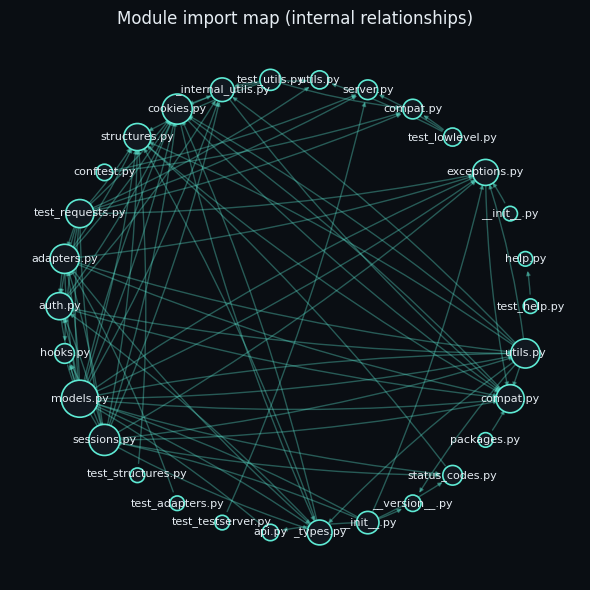

In [63]:
# --- Option A: run directly using the values from the config cell above ---
# (Skip this cell if you'd rather use the interactive form in the next cell.)

summary = analyze_and_show(
    repo_url=REPO_URL,
    provider=PROVIDER,
    api_key=API_KEY,
    model=MODEL_OVERRIDE,
    skip_ai_summary=SKIP_AI_SUMMARY,
)


In [58]:
import ipywidgets as widgets

_repo_input = widgets.Text(value=REPO_URL, description="Repo URL:", layout=widgets.Layout(width="480px"))
_provider_input = widgets.Dropdown(options=[("Groq (fast, free tier)", "groq"), ("Hugging Face Inference (free tier)", "huggingface")],
                                    value=PROVIDER, description="Provider:")
_key_input = widgets.Password(value="", description="API key:", placeholder="leave blank to be prompted securely",
                               layout=widgets.Layout(width="480px"))
_skip_ai_input = widgets.Checkbox(value=SKIP_AI_SUMMARY, description="Structure only (skip AI narrative)")
_run_button = widgets.Button(description="Analyze", button_style="success", icon="search")
_output = widgets.Output()

_last_summary = {"value": None}

def _on_click(_):
    with _output:
        _output.clear_output()
        try:
            key = _key_input.value.strip() or None
            result = analyze_and_show(
                repo_url=_repo_input.value.strip(),
                provider=_provider_input.value,
                api_key=key,
                skip_ai_summary=_skip_ai_input.value,
            )
            _last_summary["value"] = result
        except Exception as e:
            print(f"✕ {e}")

_run_button.on_click(_on_click)

display(widgets.VBox([_repo_input, _provider_input, _key_input, _skip_ai_input, _run_button, _output]))


In [59]:
# --- Export the summary as HTML report --------------------

_summary_to_export = _last_summary["value"] if "_last_summary" in dir() and _last_summary.get("value") else globals().get("summary")

if _summary_to_export:
    report_path = export_html_report(
    _summary_to_export,
    r"D:\Docs Latest\A Masters Required doc\Projects\repo_report.html"
)
    print(f"Report saved to: {report_path}")
    display(FileLink(report_path))
else:
    print("Run an analysis first (Option A or Option B above), then re-run this cell.")


Report saved to: /content/D:\Docs Latest\A Masters Required doc\Projects\repo_report.html


/content/D:\Docs Latest\A Masters Required doc\Projects\repo_report.html